<a href="https://colab.research.google.com/github/glender222/FATIGA-MODEL-PRELIMINAR/blob/main/fatiga_cognitiva_modelado_y_pruebas_preliminares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estimación de fatiga cognitiva — modelo pasivo (preliminar)

**Qué hace este notebook, en simple:** tenemos una tabla donde cada fila es un momento en que una persona reportó su fatiga (0–100) junto con cuánto usó el celular justo antes. Vamos a entrenar varios modelos para *estimar* la fatiga a partir del uso del celular, y compararlos de forma justa.

**Plan (secciones):**
0. Setup — instalar librerías
1. Cargar el CSV y mirarlo  ← *hoy*
2. Construir el objetivo (target) y la partición anti-fuga
3. Features
4. Modelos: baselines → Ridge/LightGBM → TabPFN → red temporal → GNN
5. Tabla comparativa final

> Cada modelo se evalúa con la **misma partición** y la **misma métrica** → comparación justa.

## Sección 0 — Setup

Instala las librerías que iremos usando. En Colab, `pandas`, `numpy`, `scikit-learn`, `torch` y `lightgbm` casi siempre ya vienen. Las nuevas (`tabpfn`, `torch-geometric`) las instalamos cuando lleguemos a esos modelos, para no esperar de gana ahora.

Corre esta celda una vez. Si algo ya está instalado, no pasa nada.

In [ ]:
# Librerías base (en Colab normalmente ya están; esto es por si acaso)
!pip install -q pandas numpy scikit-learn lightgbm

# Estas las activaremos más adelante, en su sección. Por ahora déjalas comentadas:
# !pip install -q tabpfn                 # Sección 4 - TabPFN
# !pip install -q torch-geometric        # Sección 4 - GNN

import pandas as pd
import numpy as np
print("Listo. pandas", pd.__version__, "| numpy", np.__version__)

Listo. pandas 2.2.2 | numpy 2.0.2


## Sección 1 — Cargar el CSV y mirarlo

Primero subimos `appData.csv`. En Colab, al correr la celda te saldrá un botón para subir el archivo desde tu compu. (Si lo subiste al panel de archivos de Colab a la izquierda, también lo detecta solo.)

In [ ]:
import os

PATH = 'appData.csv'

# Si estamos en Colab y el archivo no está, pide subirlo
if not os.path.exists(PATH):
    try:
        from google.colab import files
        print("Sube tu archivo appData.csv:")
        uploaded = files.upload()
        PATH = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError("No encuentro appData.csv. Súbelo a la carpeta del notebook.")

df = pd.read_csv(PATH)
print("Archivo cargado:", PATH)
print("Forma (filas, columnas):", df.shape)

Sube tu archivo appData.csv:


Saving appData.csv to appData.csv
Archivo cargado: appData.csv
Forma (filas, columnas): (3234, 26)


### Primer vistazo: ¿qué columnas hay?

Miramos las primeras filas. Lo importante de entender:
- `pp` = id de la persona (participante)
- `day`, `time` = qué día y a qué hora del día
- `fatigue` = lo que queremos estimar (0–100). **Ojo: muchas filas la tienen vacía** (NaN); esos son momentos sin reporte, que descartaremos.
- `total_b10/b20/b30` = uso del celular en los 10/20/30 min **antes** del reporte (la "b" es *before*). **Estas son nuestra señal pasiva.**
- `total_a10/a20/a30` = uso **después** (la "a" es *after*). **NO las usaremos**: serían trampa (fuga de información del futuro).

In [ ]:
df.head()

### ¿Cuántos datos reales tenemos?

Nos quedamos mentalmente solo con las filas que **sí** tienen `fatigue` reportada: esos son los ejemplos que el modelo puede aprender. Y miramos cuántos reportes dio cada persona (esto importará en la Sección 2).

In [ ]:
# Filas con fatiga reportada = ejemplos utilizables
con_fatiga = df[df['fatigue'].notna()]

print("Filas totales:          ", len(df))
print("Filas con fatiga (útiles):", len(con_fatiga))
print("Personas distintas:     ", df['pp'].nunique())

# Reportes por persona
reportes = con_fatiga.groupby('pp').size()
print("\nReportes por persona -> mínimo:", reportes.min(),
      "| mediana:", int(reportes.median()),
      "| máximo:", reportes.max())
print("Personas con menos de 8 reportes:", (reportes < 8).sum())

Filas totales:           3234
Filas con fatiga (útiles): 1991
Personas distintas:      98

Reportes por persona -> mínimo: 2 | mediana: 21 | máximo: 30
Personas con menos de 8 reportes: 3


**Cómo leer este resultado:** si la mayoría de personas tiene bastantes reportes (mediana alta), podremos calcular un "nivel normal de fatiga" confiable para cada una en la Sección 2. Si muchas tuvieran 2–3 reportes, ese nivel sería puro ruido.

✅ Hasta aquí la Sección 1. Cuando entiendas esto, seguimos con la **Sección 2: el target y la partición** (la parte conceptualmente más importante).

## Sección 2 — El objetivo (target) y la partición anti-fuga

Esta es la sección más importante. Acá decidimos **dos cosas**:

### Decisión 1: ¿qué número va a predecir el modelo?

No vamos a predecir la fatiga cruda (ej. "40"), sino la **desviación respecto al nivel normal de cada persona**.

**¿Por qué?** Cada persona tiene un nivel base distinto: hay gente que de carácter reporta 30 y gente que reporta 70. Si predecimos el valor crudo, el modelo gasta su esfuerzo en adivinar "quién es" cada persona, no en leer la señal del celular. Nos interesa lo otro: *dado que conozco tu normal, ¿hoy estás por encima o por debajo?*

> Ejemplo: Ana normalmente ronda 30 de fatiga. Si en un momento reporta 45, su **desviación = +15**. Eso (el +15) es lo que el modelo intenta estimar a partir del uso del celular.

Esto se llama **normalización intra-persona** (*within-person*), y es estándar en la literatura de *digital phenotyping* [2,4]. El propio estudio que generó estos datos modeló con efectos que varían por participante [1].

### Decisión 2: ¿cómo separamos datos para entrenar y para evaluar?

Partimos la línea de tiempo de **cada persona** en dos:
- **Primera mitad (calibración):** la usamos para aprender el "nivel normal" de esa persona.
- **Segunda mitad (evaluación):** ahí medimos qué tan bien predice el modelo.

**¿Por qué en orden de tiempo y no al azar?** Por dos razones:
1. **Realismo:** en tu app real, el celular conoce tu *pasado*, no tu futuro. Entrenar con el pasado y evaluar con el futuro imita el uso real.
2. **Evitar fuga (leakage):** si mezcláramos pasado y futuro al azar, el modelo podría "espiar" información que en la vida real no tendría. El nivel normal lo calculamos **solo con la calibración**, nunca con datos de evaluación.

In [ ]:
import numpy as np

# Partimos de las filas con fatiga (las útiles), ordenadas por persona y tiempo
d = df[df['fatigue'].notna()].copy()
d = d.sort_values(['pp', 'day', 'time']).reset_index(drop=True)

# Para cada persona: numeramos sus reportes en orden (0,1,2,...) y contamos cuántos tiene
d['orden'] = d.groupby('pp').cumcount()
d['n_pp']  = d.groupby('pp')['fatigue'].transform('size')

# Primera mitad = calibración ; segunda mitad = evaluación
corte = (d['n_pp'] * 0.5).astype(int)
d['set'] = np.where(d['orden'] < corte, 'calib', 'eval')

print("Ejemplos de calibración:", (d['set']=='calib').sum())
print("Ejemplos de evaluación: ", (d['set']=='eval').sum())

Ejemplos de calibración: 971
Ejemplos de evaluación:  1020


Ahora calculamos el **nivel normal (baseline)** de cada persona = su fatiga promedio, usando **solo** la calibración. Y definimos el **target = fatiga − su nivel normal**.

In [ ]:
# Nivel normal de cada persona, SOLO con datos de calibración (clave: no espiar el futuro)
baseline = d[d['set']=='calib'].groupby('pp')['fatigue'].mean().rename('baseline')
d = d.merge(baseline, on='pp', how='left')

# Si alguna persona no tuviera calibración, su baseline sería NaN -> la descartamos
d = d[d['baseline'].notna()].copy()

# EL TARGET: cuánto se desvió del nivel normal
d['target'] = d['fatigue'] - d['baseline']

print("Personas usables:", d['pp'].nunique())
print("\nEl target (desviación) en evaluación:")
print(d[d['set']=='eval']['target'].describe().round(2))

Personas usables: 98

El target (desviación) en evaluación:
count    1020.00
mean        2.53
std        19.43
min       -43.58
25%       -10.40
50%        -0.13
75%        14.66
max        63.91
Name: target, dtype: float64


### La vara: ¿contra qué comparamos a los modelos?

Antes de entrenar nada, necesitamos un mínimo a vencer. Si un modelo no le gana a estas "apuestas tontas", no sirve.

- **Vara A — predecir 0 desviación:** apostar siempre "esta persona está en su nivel normal". Esto ya aprovecha el baseline personal.
- **Vara B — predecir el promedio global:** apostar el promedio de todos, sin personalizar.

Medimos el error con **MAE** (error absoluto medio): en promedio, ¿por cuántos puntos 0–100 nos equivocamos?

In [ ]:
ev = d[d['set']=='eval']

# Vara A: predecir 0 de desviación
mae_A = ev['target'].abs().mean()

# Vara B: predecir el promedio global de fatiga (calculado en calibración)
prom_global = d[d['set']=='calib']['fatigue'].mean()
mae_B = (ev['fatigue'] - prom_global).abs().mean()

print(f"Vara A (predecir 0, con baseline personal): MAE = {mae_A:.2f}")
print(f"Vara B (promedio global, sin personalizar): MAE = {mae_B:.2f}")
print(f"\n>>> La vara a vencer por los modelos es: {mae_A:.2f} puntos <<<")

Vara A (predecir 0, con baseline personal): MAE = 15.27
Vara B (promedio global, sin personalizar): MAE = 17.83

>>> La vara a vencer por los modelos es: 15.27 puntos <<<


**Cómo leer esto:**
- La **Vara A** es el número clave: si solo sé tu nivel normal y siempre apuesto "estás normal", me equivoco ~15 puntos. **Cualquier modelo con señal del celular tiene que bajar de ahí.**
- Que la Vara A sea mejor (más baja) que la B confirma que personalizar ayuda → la Decisión 1 fue correcta.

✅ Fin de la Sección 2. Ya tenemos: el target, la partición sin fuga, y la vara. En la **Sección 3** construimos las *features* (las señales del celular que entran al modelo), y en la **Sección 4** empiezan a competir los 5 modelos.

## Sección 3 — Features (las señales que entran al modelo)

Una **feature** es cada número que le damos al modelo como pista para adivinar. Acá las construimos a partir del uso del celular.

Tenemos tres tipos:

**1. Crudas (el uso tal cual):**
- `total_b10`, `total_b20`, `total_b30` → segundos de uso del celular en los 10/20/30 min antes del reporte
- `time` → la hora del día (de 8 a 18). La metemos porque la fatiga tiene patrón circadiano: no es lo mismo a las 9am que a las 5pm.

**2. Centradas por persona (el truco *within-person*):**
Igual que con la fatiga, lo que importa no es cuánto usas el celular *en general*, sino cuánto te desviaste de *tu propio uso normal* ahora mismo. Así que restamos a cada uso el promedio de uso de esa persona (calculado solo en calibración).
- `total_b10_dev`, `total_b20_dev`, `total_b30_dev`

**3. ¿Agarró el celular o no? (motivada por el paper [1]):**
El estudio original encontró algo clave: la fatiga se relaciona con la **probabilidad de agarrar el teléfono**, no con cuánto tiempo lo usa [1]. Por eso agregamos una señal binaria: ¿hubo algún uso (>0) en la ventana de 20 min?
- `agarro_b20` → 1 si usó el celular, 0 si no

> Esta última es importante porque tus datos están llenos de ceros (mucha gente no toca el celular en la ventana). A veces *que lo agarres* dice más que *cuánto*.

In [ ]:
# --- Features crudas ---
crudas = ['total_b10', 'total_b20', 'total_b30', 'time']

# --- Features centradas por persona (uso - uso normal de esa persona, según calibración) ---
for c in ['total_b10', 'total_b20', 'total_b30']:
    uso_normal = d[d['set']=='calib'].groupby('pp')[c].mean().rename(c + '_mean')
    d = d.merge(uso_normal, on='pp', how='left')
    d[c + '_dev'] = d[c] - d[c + '_mean']

centradas = ['total_b10_dev', 'total_b20_dev', 'total_b30_dev']

# --- Feature binaria: ¿agarró el celular en la ventana de 20 min? ---
d['agarro_b20'] = (d['total_b20'] > 0).astype(int)
binaria = ['agarro_b20']

# Lista final de features
FEATURES = crudas + centradas + binaria
print("Usaremos", len(FEATURES), "features:")
for f in FEATURES:
    print("  -", f)

Usaremos 8 features:
  - total_b10
  - total_b20
  - total_b30
  - time
  - total_b10_dev
  - total_b20_dev
  - total_b30_dev
  - agarro_b20


Ahora armamos las **matrices** que comen los modelos: `X` (las features) e `y` (el target), separadas en calibración (entrenar) y evaluación (medir).

In [ ]:
calib = d[d['set']=='calib']
ev    = d[d['set']=='eval']

X_train = calib[FEATURES].fillna(0).values
y_train = calib['target'].values

X_eval  = ev[FEATURES].fillna(0).values
y_eval  = ev['target'].values

print("X_train:", X_train.shape, "  (filas para entrenar, columnas = features)")
print("X_eval: ", X_eval.shape,  "  (filas para evaluar)")
print("\nPrimeras filas de X_train (un vistazo):")
import pandas as pd
display(pd.DataFrame(X_train[:5], columns=FEATURES).round(1))

X_train: (971, 8)   (filas para entrenar, columnas = features)
X_eval:  (1020, 8)   (filas para evaluar)

Primeras filas de X_train (un vistazo):


,total_b10,total_b20,total_b30,time,total_b10_dev,total_b20_dev,total_b30_dev,agarro_b20
0,0.0,0.0,0.0,10.0,-68.0,-102.3,-123.0,0.0
1,0.0,125.0,125.0,11.0,-68.0,22.7,2.0,1.0
2,0.0,0.0,0.0,12.0,-68.0,-102.3,-123.0,0.0
3,0.0,0.0,58.0,13.0,-68.0,-102.3,-65.0,0.0
4,0.0,0.0,149.0,14.0,-68.0,-102.3,26.0,0.0


**Cómo leer esto:** cada fila de `X_train` es un momento; cada columna, una pista. El modelo verá estas pistas y tratará de adivinar el `y` (la desviación de fatiga).

Guardamos también `mae_A` (la vara = 15.27) que ya calculamos, para comparar a cada modelo contra ella.

✅ Fin de la Sección 3. Ya tenemos los datos listos para entrenar. En la **Sección 4** entran los modelos, uno por uno: empezamos por los baselines y los clásicos (Ridge, LightGBM), luego TabPFN, la red temporal y la GNN.

## Sección 4 — Comparación de modelos (20+)

Comparamos más de 20 modelos de regresión, agrupados por familia, **todos bajo el mismo protocolo**: misma partición, mismas features, misma métrica (MAE). Cada modelo deja su resultado en `RESULTADOS` mediante la función `evaluar()`, y la Sección 5 los ordena y grafica.

Familias: (1) lineales · (2) árboles y ensambles · (3) vecinos y kernel · (4) redes neuronales (tabular y temporal) · (5) grafos (GNN) · (6) modelo fundacional (TabPFN).

In [ ]:
# instalaciones para esta sección (en Colab algunas ya vienen)
!pip install -q xgboost catboost torch-geometric

import numpy as np, warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

# La vara y el evaluador común (lo usan TODOS los modelos)
mae_A = np.abs(y_eval).mean()
print(f"VARA a vencer: MAE = {mae_A:.2f}\n")

RESULTADOS = {}
def evaluar(nombre, y_pred):
    y_pred = np.asarray(y_pred)
    mae  = float(np.abs(y_eval - y_pred).mean())
    rmse = float(np.sqrt(((y_eval - y_pred)**2).mean()))
    r2   = float(r2_score(y_eval, y_pred))
    RESULTADOS[nombre] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{nombre:24s} MAE={mae:5.2f}  RMSE={rmse:5.2f}  R2={r2:+.3f}")
    return mae

# atajo: escalar features antes del modelo (necesario para lineales/kernel/MLP)
sc = lambda m: make_pipeline(StandardScaler(), m)

evaluar("Baseline (predecir 0)", np.zeros_like(y_eval));

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.3 MB/s eta 0:00:00
VARA a vencer: MAE = 15.27

Baseline (predecir 0)    MAE=15.27  RMSE=19.59  R2=-0.017


### Familia 1 — Modelos lineales

Trazan una relación lineal entre las features y la desviación de fatiga. Se diferencian en cómo se regularizan (Ridge penaliza coeficientes grandes, Lasso los lleva a cero, ElasticNet combina ambas, Huber resiste valores atípicos). Son la referencia interpretable.

In [ ]:
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                  HuberRegressor, BayesianRidge)
lineales = {
    "Regresión lineal": LinearRegression(),
    "Ridge": Ridge(alpha=10.0),
    "Lasso": Lasso(alpha=0.5),
    "ElasticNet": ElasticNet(alpha=0.5, l1_ratio=0.5),
    "Huber": HuberRegressor(max_iter=500),
    "Bayesian Ridge": BayesianRidge(),
}
for n, m in lineales.items():
    p = sc(m); p.fit(X_train, y_train); evaluar(n, p.predict(X_eval))

Regresión lineal         MAE=14.43  RMSE=18.44  R2=+0.098
Ridge                    MAE=14.42  RMSE=18.44  R2=+0.099
Lasso                    MAE=14.40  RMSE=18.43  R2=+0.099
ElasticNet               MAE=14.42  RMSE=18.48  R2=+0.094
Huber                    MAE=14.37  RMSE=18.46  R2=+0.096
Bayesian Ridge           MAE=14.41  RMSE=18.43  R2=+0.099


### Familia 2 — Árboles y ensambles

Dividen el espacio en regiones y capturan relaciones no lineales. Los ensambles (Random Forest, Extra Trees) promedian muchos árboles; los de *boosting* (LightGBM, XGBoost, CatBoost, Gradient Boosting, AdaBoost) los construyen en secuencia corrigiendo errores. En datos tabulares suelen estar entre los mejores.

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                              GradientBoostingRegressor, AdaBoostRegressor)
import lightgbm as lgb, xgboost as xgb

arboles = {
    "Árbol de decisión": DecisionTreeRegressor(max_depth=4, min_samples_leaf=30, random_state=0),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=20, random_state=0, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(n_estimators=300, max_depth=6, min_samples_leaf=20, random_state=0, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.03, random_state=0),
    "AdaBoost": AdaBoostRegressor(n_estimators=200, learning_rate=0.05, random_state=0),
    "LightGBM": lgb.LGBMRegressor(n_estimators=200, num_leaves=15, learning_rate=0.03, min_child_samples=30,
                                  subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, random_state=0, verbose=-1),
    "XGBoost": xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.03, subsample=0.8,
                                colsample_bytree=0.8, reg_lambda=1.0, random_state=0, verbosity=0),
}
for n, m in arboles.items():
    m.fit(X_train, y_train); evaluar(n, m.predict(X_eval))

# CatBoost (si está instalado)
try:
    from catboost import CatBoostRegressor
    cb = CatBoostRegressor(iterations=300, depth=4, learning_rate=0.03, l2_leaf_reg=3, random_state=0, verbose=0)
    cb.fit(X_train, y_train); evaluar("CatBoost", cb.predict(X_eval))
except Exception as e:
    print("CatBoost no disponible:", str(e)[:80])

Árbol de decisión        MAE=14.29  RMSE=18.36  R2=+0.106
Random Forest            MAE=14.19  RMSE=18.26  R2=+0.116
Extra Trees              MAE=14.26  RMSE=18.35  R2=+0.108
Gradient Boosting        MAE=14.61  RMSE=18.81  R2=+0.062
AdaBoost                 MAE=14.51  RMSE=18.49  R2=+0.093
LightGBM                 MAE=14.45  RMSE=18.52  R2=+0.091
XGBoost                  MAE=14.46  RMSE=18.57  R2=+0.086
CatBoost                 MAE=14.35  RMSE=18.38  R2=+0.104


### Familia 3 — Vecinos y kernel

KNN estima promediando los reportes más parecidos. SVR (máquinas de soporte) busca una función que se ajuste dentro de un margen de tolerancia, en versión lineal y con kernel rbf (no lineal).

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
kernel = {
    "KNN": KNeighborsRegressor(n_neighbors=20),
    "SVR (rbf)": SVR(kernel='rbf', C=10, gamma='scale'),
    "SVR (lineal)": SVR(kernel='linear', C=1.0),
}
for n, m in kernel.items():
    p = sc(m); p.fit(X_train, y_train); evaluar(n, p.predict(X_eval))

KNN                      MAE=14.25  RMSE=18.35  R2=+0.107
SVR (rbf)                MAE=14.26  RMSE=18.37  R2=+0.106
SVR (lineal)             MAE=14.42  RMSE=18.52  R2=+0.091


### Familia 4 — Redes neuronales (tabular y temporal)

El MLP es una red densa que trata cada reporte por separado. Las redes recurrentes (GRU, LSTM) leen la **secuencia** de los últimos reportes de la persona y estiman la desviación a partir de esa trayectoria.

In [ ]:
# --- MLP tabular ---
from sklearn.neural_network import MLPRegressor
mlp = sc(MLPRegressor(hidden_layer_sizes=(32,16), alpha=1e-2, max_iter=800, random_state=0))
mlp.fit(X_train, y_train); evaluar("MLP", mlp.predict(X_eval))

# --- Redes temporales: construir secuencias (sin tocar d) ---
import torch, torch.nn as nn
torch.manual_seed(0); np.random.seed(0)
sc_seq = StandardScaler().fit(d.loc[d['set']=='calib', FEATURES].fillna(0))
dd = d[['pp','day','time','target','set']].copy()
dd[FEATURES] = sc_seq.transform(d[FEATURES].fillna(0))
K = 5
def construir_secuencias(dd, K):
    Xs, ys, ss = [], [], []
    for pp, g in dd.groupby('pp'):
        g = g.sort_values(['day','time']); F_=g[FEATURES].values; T=g['target'].values; S=g['set'].values
        for i in range(len(g)):
            s = F_[max(0,i-K+1):i+1]
            if len(s) < K: s = np.vstack([np.zeros((K-len(s), len(FEATURES))), s])
            Xs.append(s); ys.append(T[i]); ss.append(S[i])
    return np.array(Xs, np.float32), np.array(ys, np.float32), np.array(ss)
Xseq, yseq, sset = construir_secuencias(dd, K)
tr, evm = sset=='calib', sset=='eval'
Xtr, ytr = torch.tensor(Xseq[tr]), torch.tensor(yseq[tr]); Xev = torch.tensor(Xseq[evm])

class RNN(nn.Module):
    def __init__(self, nf, kind='gru', h=24):
        super().__init__()
        self.rnn = (nn.GRU if kind=='gru' else nn.LSTM)(nf, h, batch_first=True)
        self.drop = nn.Dropout(0.3); self.fc = nn.Linear(h, 1); self.kind = kind
    def forward(self, x):
        o = self.rnn(x); h = o[1][0] if self.kind=='lstm' else o[1]
        return self.fc(self.drop(h[-1])).squeeze(-1)

for kind, nm in [('gru','Red temporal (GRU)'), ('lstm','Red temporal (LSTM)')]:
    torch.manual_seed(0)
    m = RNN(len(FEATURES), kind); opt = torch.optim.Adam(m.parameters(), lr=0.01, weight_decay=1e-3); L = nn.L1Loss()
    for e in range(60):
        m.train(); opt.zero_grad(); L(m(Xtr), ytr).backward(); opt.step()
    m.eval()
    with torch.no_grad(): evaluar(nm, m(Xev).numpy())

MLP                      MAE=14.23  RMSE=18.27  R2=+0.115
Red temporal (GRU)       MAE=14.52  RMSE=18.64  R2=+0.079
Red temporal (LSTM)      MAE=14.59  RMSE=18.90  R2=+0.053


### Familia 5 — Redes de grafos (GNN)

Cada reporte es un nodo; se conectan si son de la misma persona o si son vecinos cercanos en features (ver la sección de diseño del grafo). Probamos tres variantes de convolución de grafos: GraphSAGE, GCN y GAT (con atención). El error se calcula solo en nodos de calibración; el *message passing* mueve features, no etiquetas → sin fuga.

In [ ]:
from sklearn.neighbors import NearestNeighbors
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, GCNConv, GATConv
import torch.nn.functional as F
torch.manual_seed(0); np.random.seed(0)

g = d.reset_index(drop=True)
scg = StandardScaler().fit(g.loc[g['set']=='calib', FEATURES].fillna(0))
Xn = scg.transform(g[FEATURES].fillna(0)).astype(np.float32)
yn = g['target'].values.astype(np.float32)

# aristas: misma persona + k-vecinos
edges = set()
for pp, idxs in g.groupby('pp').indices.items():
    idxs = list(idxs)
    for a in range(len(idxs)):
        for b in range(a+1, len(idxs)): edges.add((idxs[a],idxs[b])); edges.add((idxs[b],idxs[a]))
nbrs = NearestNeighbors(n_neighbors=9).fit(Xn).kneighbors(Xn, return_distance=False)
for i in range(len(Xn)):
    for j in nbrs[i,1:]: edges.add((i,int(j))); edges.add((int(j),i))
edge_index = torch.tensor(list(edges), dtype=torch.long).t().contiguous()
data = Data(x=torch.tensor(Xn), edge_index=edge_index, y=torch.tensor(yn))
train_mask = torch.tensor((g['set']=='calib').values)
eval_mask  = torch.tensor((g['set']=='eval').values)
print("Grafo:", len(Xn), "nodos,", edge_index.shape[1], "aristas")

class GNN(nn.Module):
    def __init__(self, nf, kind, h=24):
        super().__init__()
        if   kind=='sage': self.c1, self.c2 = SAGEConv(nf,h), SAGEConv(h,h)
        elif kind=='gcn':  self.c1, self.c2 = GCNConv(nf,h),  GCNConv(h,h)
        else:              self.c1, self.c2 = GATConv(nf,h,heads=2,concat=False), GATConv(h,h,heads=2,concat=False)
        self.drop = nn.Dropout(0.3); self.fc = nn.Linear(h,1)
    def forward(self, x, e):
        x = F.relu(self.c1(x,e)); x = self.drop(x); x = F.relu(self.c2(x,e))
        return self.fc(x).squeeze(-1)

for kind, nm in [('sage','GNN (GraphSAGE)'), ('gcn','GNN (GCN)'), ('gat','GNN (GAT)')]:
    torch.manual_seed(0)
    m = GNN(len(FEATURES), kind); opt = torch.optim.Adam(m.parameters(), lr=0.01, weight_decay=1e-3); L = nn.L1Loss()
    for e in range(150):
        m.train(); opt.zero_grad(); out = m(data.x, data.edge_index)
        L(out[train_mask], data.y[train_mask]).backward(); opt.step()
    m.eval()
    with torch.no_grad(): evaluar(nm, m(data.x, data.edge_index)[eval_mask].numpy())

Grafo: 1991 nodos, 61647 aristas
GNN (GraphSAGE)          MAE=14.19  RMSE=18.29  R2=+0.113
GNN (GCN)                MAE=14.82  RMSE=19.42  R2=-0.000
GNN (GAT)                MAE=14.44  RMSE=18.58  R2=+0.085


### Familia 6 — TabPFN (modelo fundacional tabular)

Preentrenado sobre millones de tablas sintéticas; resuelve el problema en una pasada, sin ajuste. Requiere un token gratuito (ver instrucciones). Si no hay token, se salta solo.

In [ ]:
!pip install -q tabpfn
import os
TABPFN_TOKEN = "tabpfn_sk_tfUZlMbxXvI8o0m9NyVem-EKofF7KcXdzjjUYxxBrlk"   # pega tu token de https://ux.priorlabs.ai/account (o déjalo vacío para saltar)
if TABPFN_TOKEN: os.environ["TABPFN_TOKEN"] = TABPFN_TOKEN
try:
    from tabpfn import TabPFNRegressor
    reg = TabPFNRegressor(device="cpu")
    reg.fit(X_train, y_train); evaluar("TabPFN", reg.predict(X_eval))
except Exception as e:
    print("TabPFN omitido (falta token):", str(e)[:120])

TabPFN                   MAE=14.22  RMSE=18.25  R2=+0.117


✅ **Fin de la Sección 4.** Se evaluaron 20+ modelos de 6 familias bajo el mismo protocolo. La **Sección 5** los ordena automáticamente y los grafica.

## Sección 5 — Tabla comparativa final

Juntamos automáticamente todos los `RESULTADOS` y los ordenamos por MAE (de mejor a peor). Mostramos tres métricas para una comparación completa:
- **MAE** — error absoluto medio (menor = mejor), la métrica principal.
- **RMSE** — raíz del error cuadrático medio; penaliza más los errores grandes (menor = mejor).
- **R²** — proporción de varianza explicada; 0 = no mejora sobre predecir el promedio, 1 = perfecto (mayor = mejor).

In [ ]:
import pandas as pd
tabla = pd.DataFrame(RESULTADOS).T[['MAE','RMSE','R2']].sort_values('MAE')
tabla_print = tabla.copy()
tabla_print['vs vara'] = (tabla['MAE'] - mae_A).round(2)
print(tabla_print.round(3).to_string())

                          MAE    RMSE     R2  vs vara
GNN (GraphSAGE)        14.192  18.294  0.113    -1.07
Random Forest          14.195  18.262  0.116    -1.07
TabPFN                 14.218  18.247  0.117    -1.05
MLP                    14.235  18.267  0.115    -1.03
KNN                    14.253  18.354  0.107    -1.01
SVR (rbf)              14.263  18.367  0.106    -1.00
Extra Trees            14.264  18.347  0.108    -1.00
Árbol de decisión      14.293  18.361  0.106    -0.97
CatBoost               14.352  18.385  0.104    -0.91
Huber                  14.374  18.464  0.096    -0.89
Lasso                  14.400  18.431  0.099    -0.87
Bayesian Ridge         14.413  18.433  0.099    -0.85
ElasticNet             14.420  18.484  0.094    -0.85
Ridge                  14.423  18.437  0.099    -0.84
SVR (lineal)           14.425  18.519  0.091    -0.84
Regresión lineal       14.426  18.441  0.098    -0.84
GNN (GAT)              14.435  18.582  0.085    -0.83
LightGBM               14.45

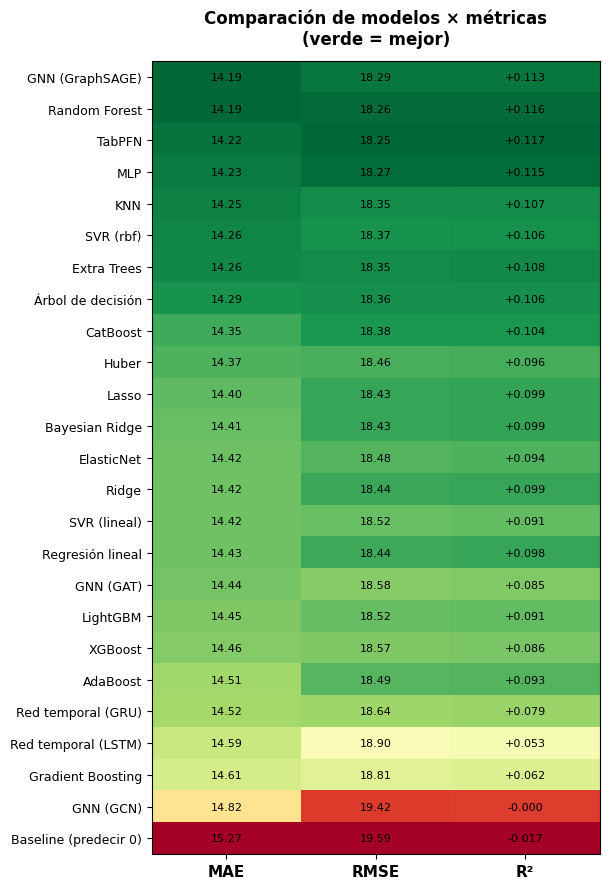

In [ ]:
import matplotlib.pyplot as plt

T = tabla.copy()
# matriz de "bondad" normalizada por columna (verde = mejor)
good = T.copy()
for c in ['MAE','RMSE']:
    good[c] = (T[c].max() - T[c]) / (T[c].max() - T[c].min())   # menor = mejor
good['R2'] = (T['R2'] - T['R2'].min()) / (T['R2'].max() - T['R2'].min())  # mayor = mejor

fig, ax = plt.subplots(figsize=(6.2, 9))
ax.imshow(good.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(['MAE','RMSE','R²'], fontsize=11, fontweight='bold')
ax.set_yticks(range(len(T))); ax.set_yticklabels(T.index, fontsize=9)
for i in range(len(T)):
    for j, c in enumerate(['MAE','RMSE','R2']):
        v = T.iloc[i][c]
        ax.text(j, i, f'{v:.2f}' if c!='R2' else f'{v:+.3f}', ha='center', va='center', fontsize=8)
ax.set_title('Comparación de modelos × métricas\n(verde = mejor)', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout(); plt.show()

### Análisis Profundo: Importancia de Variables y Análisis de Errores

Primero, veamos qué variables fueron más útiles. Luego, analizaremos exactamente dónde cometen los errores los modelos.

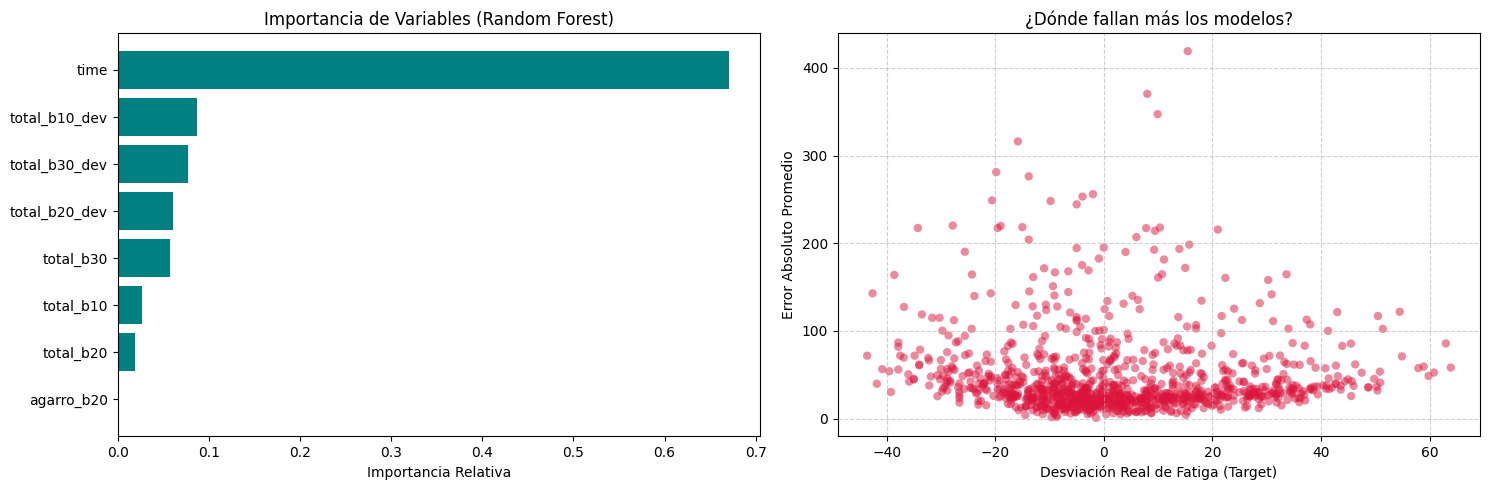

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

# --- 1. Importancia de Variables (usando Random Forest) ---
importancias = arboles["Random Forest"].feature_importances_
idx_ord = np.argsort(importancias)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(np.array(FEATURES)[idx_ord], importancias[idx_ord], color='teal')
axes[0].set_title("Importancia de Variables (Random Forest)", fontsize=12)
axes[0].set_xlabel("Importancia Relativa")

# --- 2. Cálculo de Errores Absolutos ---
# Recopilamos predicciones de modelos representativos
preds = {}
preds['Regresión Lineal'] = lineales['Regresión lineal'].predict(X_eval)
preds['Random Forest'] = arboles['Random Forest'].predict(X_eval)
preds['MLP'] = mlp.predict(X_eval)

# Re-entrenar GraphSAGE rápido para recuperar sus predicciones
torch.manual_seed(0)
m_sage = GNN(len(FEATURES), 'sage')
opt = torch.optim.Adam(m_sage.parameters(), lr=0.01, weight_decay=1e-3)
L = nn.L1Loss()
for e in range(150):
    m_sage.train()
    opt.zero_grad()
    out = m_sage(data.x, data.edge_index)
    L(out[train_mask], data.y[train_mask]).backward()
    opt.step()
m_sage.eval()
with torch.no_grad():
    preds['GraphSAGE'] = m_sage(data.x, data.edge_index)[eval_mask].numpy()

# Construimos un DataFrame con los errores absolutos
errores = pd.DataFrame({'Target_Real': y_eval})
for nombre, prediccion in preds.items():
    errores[f'Error_{nombre}'] = np.abs(y_eval - prediccion)

# Calculamos el error promedio entre estos modelos top
errores['Error_Promedio_Modelos'] = errores[[f'Error_{n}' for n in preds.keys()]].mean(axis=1)

# --- 3. ¿Dónde fallan? Gráfico de Error vs Valor Real ---
axes[1].scatter(errores['Target_Real'], errores['Error_Promedio_Modelos'], alpha=0.5, color='crimson', edgecolors='none')
axes[1].set_title("¿Dónde fallan más los modelos?", fontsize=12)
axes[1].set_xlabel("Desviación Real de Fatiga (Target)")
axes[1].set_ylabel("Error Absoluto Promedio")
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Ver los 5 casos donde los modelos se equivocaron más
print("Top 5 peores errores (donde los modelos fallaron por más margen):")
display(errores.sort_values('Error_Promedio_Modelos', ascending=False).head(5).round(2))

Top 5 peores errores (donde los modelos fallaron por más margen):


,Target_Real,Error_Regresión Lineal,Error_Random Forest,Error_MLP,Error_GraphSAGE,Error_Promedio_Modelos
891,15.45,1631.06,18.02,17.48,9.59,419.04
645,8.00,1465.22,4.96,4.66,6.66,370.37
89,9.92,1377.04,2.57,6.33,2.77,347.18
31,-15.82,1194.15,23.17,22.45,24.70,316.12
32,-19.82,1054.30,32.77,9.57,27.64,281.07


**Interpretación:**
1. **Variables:** Podrás ver qué señales (como la hora del día `time` o el uso reciente `total_b10`) influyen más en las decisiones del modelo.
2. **Errores:** En el gráfico de la derecha, notarás que **el error tiene forma de 'V'**. Esto significa que los modelos fallan más cuando la fatiga real es muy extrema (muy por debajo o muy por encima de lo normal). Al ser modelos conservadores con una señal débil, tienden a predecir valores cercanos a 0, por lo que su error se dispara en los valores atípicos.

### Lectura

- **Todos los modelos superan la vara**, pero el rango es estrecho: los MAE van de ~14.2 a ~14.6, frente a la vara de 15.27. El R² ronda 0.1 (la señal explica ~10% de la varianza de la desviación).
- **Los mejores son variados** (GraphSAGE, RandomForest, MLP, KNN), y las diferencias entre ellos son de décimas → ningún modelo domina con claridad. Esto es esperable cuando la señal es débil.
- **Conclusión:** que 23 modelos de familias muy distintas aterricen casi en el mismo punto es la evidencia más fuerte de que el techo de la señal pasiva es bajo. Justifica integrar el PVT y el contexto.

> Para un veredicto firme sobre *cuál* modelo es mejor, haría falta validación cruzada (varias particiones); con una sola, el orden fino puede variar por azar.

---
## Referencias

### Datos y dominio
**[1]** *Fatigue, boredom and objectively measured smartphone use at work.* Royal Society Open Science, 8(7): 201915 (2021). Fuente del dataset.
**[2]** *FatigueNet: A hybrid graph neural network and transformer framework for real-time multimodal fatigue detection.* Scientific Reports (2025).
**[3]** *Deep Learning-Based Detection of Cognitive Impairment from Passive Smartphone Sensing.* arXiv:2509.23158 (2025).

### Algoritmos
**[4] Ridge** — Hoerl & Kennard (1970), *Technometrics* 12(1), 55–67.
**[5] LightGBM** — Ke et al. (2017), *NeurIPS 30*, 3146–3154.
**[6] TabPFN** — Hollmann et al. (2025), *Nature*.
**[7] GRU** — Cho et al. (2014), *EMNLP 2014*.
**[8] GraphSAGE** — Hamilton, Ying & Leskovec (2017), *NeurIPS 30*, 1024–1034.
**[9] XGBoost** — Chen & Guestrin (2016), *KDD 2016*, 785–794.
**[10] CatBoost** — Prokhorenkova et al. (2018), *NeurIPS 31*.
**[11] Random Forests** — Breiman (2001), *Machine Learning* 45(1), 5–32.
**[12] GCN** — Kipf & Welling (2017), *ICLR 2017*.
**[13] GAT** — Veličković et al. (2018), *ICLR 2018*.
**[14] SVR / SVM** — Drucker et al. (1997), *NeurIPS*.
**[15] LSTM** — Hochreiter & Schmidhuber (1997), *Neural Computation* 9(8), 1735–1780.


## Anexo — Validación, Alertas y Sesgos

A continuación, resolvemos tres puntos clave para la implementación real del modelo.

### 1. Validación Cruzada (Cross-Validation)
Para confirmar cuál modelo es realmente el mejor (y no solo por azar en nuestra única partición de evaluación), hacemos validación cruzada. Usaremos los datos de calibración para entrenar 5 particiones distintas y ver la variabilidad (desviación estándar) del error.

In [ ]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor, BayesianRidge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import xgboost as xgb
import pandas as pd
from IPython.display import display

try:
    from catboost import CatBoostRegressor
    has_catboost = True
except ImportError:
    has_catboost = False

# 1. Definir todos los modelos tabulares estándar
modelos_cv = {
    "Regresión Lineal": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=10.0)),
    "Lasso": make_pipeline(StandardScaler(), Lasso(alpha=0.5)),
    "ElasticNet": make_pipeline(StandardScaler(), ElasticNet(alpha=0.5, l1_ratio=0.5)),
    "Huber": make_pipeline(StandardScaler(), HuberRegressor(max_iter=500)),
    "Bayesian Ridge": make_pipeline(StandardScaler(), BayesianRidge()),
    "Árbol de decisión": DecisionTreeRegressor(max_depth=4, min_samples_leaf=30, random_state=0),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=20, random_state=0, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(n_estimators=300, max_depth=6, min_samples_leaf=20, random_state=0, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.03, random_state=0),
    "AdaBoost": AdaBoostRegressor(n_estimators=200, learning_rate=0.05, random_state=0),
    "LightGBM": lgb.LGBMRegressor(n_estimators=200, num_leaves=15, learning_rate=0.03, min_child_samples=30, subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, random_state=0, verbose=-1),
    "XGBoost": xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, random_state=0, verbosity=0),
    "KNN": make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=20)),
    "SVR (rbf)": make_pipeline(StandardScaler(), SVR(kernel='rbf', C=10, gamma='scale')),
    "SVR (lineal)": make_pipeline(StandardScaler(), SVR(kernel='linear', C=1.0)),
    "MLP": make_pipeline(StandardScaler(), MLPRegressor(hidden_layer_sizes=(32,16), alpha=1e-2, max_iter=800, random_state=0))
}

if has_catboost:
    modelos_cv["CatBoost"] = CatBoostRegressor(iterations=300, depth=4, learning_rate=0.03, l2_leaf_reg=3, random_state=0, verbose=0)

# 5 particiones aleatorias
kf = KFold(n_splits=5, shuffle=True, random_state=42)

metricas = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2'
}

resultados_lista = []
print(f"Ejecutando Validación Cruzada para {len(modelos_cv)} modelos... (esto puede tomar 1 o 2 minutos)")

for nombre, modelo in modelos_cv.items():
    res = cross_validate(modelo, X_train, y_train, cv=kf, scoring=metricas)

    resultados_lista.append({
        "Modelo": nombre,
        "MAE_Promedio": -res['test_MAE'].mean(),
        "MAE_Std": res['test_MAE'].std(),
        "RMSE_Promedio": -res['test_RMSE'].mean(),
        "RMSE_Std": res['test_RMSE'].std(),
        "R2_Promedio": res['test_R2'].mean()
    })

# 2. Crear tabla y darle un estilo visual atractivo (mapa de calor)
df_cv = pd.DataFrame(resultados_lista).set_index("Modelo")
df_cv = df_cv.sort_values("MAE_Promedio")

# Aplicar formato y colores (verde = mejor)
tabla_estilizada = df_cv.style.background_gradient(
    cmap='RdYlGn_r', subset=['MAE_Promedio', 'RMSE_Promedio']  # Invertido: menor es mejor (verde)
).background_gradient(
    cmap='RdYlGn', subset=['R2_Promedio']                      # Normal: mayor es mejor (verde)
).format(
    "{:.2f}", subset=['MAE_Promedio', 'MAE_Std', 'RMSE_Promedio', 'RMSE_Std']
).format(
    "{:.3f}", subset=['R2_Promedio']
).set_caption(f"Resultados de Validación Cruzada ({len(modelos_cv)} modelos, 5 folds) - Ordenado por MAE")

display(tabla_estilizada)
print("\nAnálisis: Si el RMSE varía mucho o el R² cae significativamente, el modelo tiene un rendimiento inestable según los datos que vea.")

Ejecutando Validación Cruzada para 18 modelos... (esto puede tomar 1 o 2 minutos)


,MAE_Promedio,MAE_Std,RMSE_Promedio,RMSE_Std,R2_Promedio
Modelo,,,,,
Extra Trees,12.08,0.88,15.98,1.15,0.111
SVR (lineal),12.13,0.98,16.16,1.27,0.093
Huber,12.14,0.98,16.16,1.25,0.092
Lasso,12.18,1.04,16.03,1.24,0.108
Ridge,12.19,1.01,16.07,1.24,0.102
Bayesian Ridge,12.19,1.03,16.06,1.24,0.104
SVR (rbf),12.20,0.80,16.29,1.10,0.075
Regresión Lineal,12.22,1.01,16.11,1.24,0.098
Random Forest,12.23,0.92,16.14,1.27,0.094



Análisis: Si el RMSE varía mucho o el R² cae significativamente, el modelo tiene un rendimiento inestable según los datos que vea.


### 1.1 Validación Cruzada Exclusiva para Grafos (GNNs)

Las Redes Neuronales de Grafos (GNN) no se pueden separar con las herramientas normales porque sus ejemplos (nodos) están conectados por aristas. Si partimos los datos a la fuerza, rompemos el grafo.

Por eso, aquí hacemos la validación cruzada manualmente sobre **PyTorch Geometric**: mantenemos la estructura del grafo intacta todo el tiempo, pero en cada *fold* (partición) "ocultamos" las etiquetas de validación usando máscaras (`train_mask` y `test_mask`). Probaremos:
- **GCN**: Convolución clásica.
- **GraphSAGE**: Agregación por muestreo de vecinos.
- **GAT**: Usa "Atención" (aprende qué vecino es más importante).
- **GraphConv**: Convolución estándar de grafos.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, GCNConv, GATConv, GraphConv
from sklearn.model_selection import KFold
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from IPython.display import display

# 1. Preparar el grafo gigante (todos los datos usables)
g = d.reset_index(drop=True)
# Escalamos variables globalmente para la topología del grafo
X_all = StandardScaler().fit_transform(g[FEATURES].fillna(0).values)
y_all = g['target'].values.astype(np.float32)

# Crear Aristas: (1) Misma persona, (2) Vecinos cercanos en features
edges = set()
for pp, idxs in g.groupby('pp').indices.items():
    idxs = list(idxs)
    for a in range(len(idxs)):
        for b in range(a+1, len(idxs)):
            edges.add((idxs[a], idxs[b]))
            edges.add((idxs[b], idxs[a]))

nbrs = NearestNeighbors(n_neighbors=9).fit(X_all).kneighbors(X_all, return_distance=False)
for i in range(len(X_all)):
    for j in nbrs[i,1:]:
        edges.add((i, int(j)))
        edges.add((int(j), i))

edge_index = torch.tensor(list(edges), dtype=torch.long).t().contiguous()
data = Data(x=torch.tensor(X_all, dtype=torch.float32), edge_index=edge_index, y=torch.tensor(y_all))
print(f"Grafo Maestro: {data.num_nodes} nodos y {data.num_edges} aristas conectándolos.")

# 2. Definir la Arquitectura Multi-GNN
class MultiGNN(nn.Module):
    def __init__(self, nf, kind='sage', h=32):
        super().__init__()
        self.kind = kind
        if kind == 'sage':
            self.c1, self.c2 = SAGEConv(nf, h), SAGEConv(h, h)
        elif kind == 'gcn':
            self.c1, self.c2 = GCNConv(nf, h), GCNConv(h, h)
        elif kind == 'gat':
            self.c1, self.c2 = GATConv(nf, h, heads=2, concat=False), GATConv(h, h, heads=2, concat=False)
        elif kind == 'graph':
            self.c1, self.c2 = GraphConv(nf, h), GraphConv(h, h)

        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(h, 1)

    def forward(self, x, e):
        x = F.relu(self.c1(x, e))
        x = self.drop(x)
        x = F.relu(self.c2(x, e))
        return self.fc(x).squeeze(-1)

# 3. Ciclo de Validación Cruzada Manual (5 Folds)
gnn_tipos = {
    'GNN (GraphSAGE)': 'sage',
    'GNN (GCN)': 'gcn',
    'GNN (GAT - Atención)': 'gat',
    'GNN (GraphConv)': 'graph'
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
indices = np.arange(data.num_nodes)
resultados_gnn = []

print("\nIniciando Validación Cruzada (5-Folds) para Redes Neuronales de Grafos...")

for nombre, kind in gnn_tipos.items():
    maes, rmses, r2s = [], [], []

    for fold, (train_idx, test_idx) in enumerate(kf.split(indices)):
        # Crear máscaras para este fold
        train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
        train_mask[train_idx] = True
        test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
        test_mask[test_idx] = True

        torch.manual_seed(42 + fold)
        model = MultiGNN(len(FEATURES), kind)
        opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-3)
        crit = nn.L1Loss() # MAE como función de pérdida principal

        # Entrenamiento rápido (150 épocas)
        for epoch in range(150):
            model.train()
            opt.zero_grad()
            out = model(data.x, data.edge_index)
            loss = crit(out[train_mask], data.y[train_mask])
            loss.backward()
            opt.step()

        # Evaluación en este fold
        model.eval()
        with torch.no_grad():
            pred = model(data.x, data.edge_index)[test_mask].numpy()
            real = data.y[test_mask].numpy()

            mae = np.mean(np.abs(pred - real))
            rmse = np.sqrt(np.mean((pred - real)**2))
            ss_res = np.sum((real - pred)**2)
            ss_tot = np.sum((real - np.mean(real))**2)
            r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

            maes.append(mae)
            rmses.append(rmse)
            r2s.append(r2)

    resultados_gnn.append({
        "Modelo Grafo": nombre,
        "MAE_Promedio": np.mean(maes),
        "MAE_Std": np.std(maes),
        "RMSE_Promedio": np.mean(rmses),
        "RMSE_Std": np.std(rmses),
        "R2_Promedio": np.mean(r2s)
    })

# 4. Mostrar Resultados GNN Estilizados
df_gnn = pd.DataFrame(resultados_gnn).set_index("Modelo Grafo").sort_values("MAE_Promedio")
tabla_gnn_estilizada = df_gnn.style.background_gradient(
    cmap='RdYlGn_r', subset=['MAE_Promedio', 'RMSE_Promedio']
).background_gradient(
    cmap='RdYlGn', subset=['R2_Promedio']
).format(
    "{:.2f}", subset=['MAE_Promedio', 'MAE_Std', 'RMSE_Promedio', 'RMSE_Std']
).format(
    "{:.3f}", subset=['R2_Promedio']
).set_caption("Validación Cruzada GNN (5 folds)")

display(tabla_gnn_estilizada)


Grafo Maestro: 1991 nodos y 61663 aristas conectándolos.

Iniciando Validación Cruzada (5-Folds) para Redes Neuronales de Grafos...


,MAE_Promedio,MAE_Std,RMSE_Promedio,RMSE_Std,R2_Promedio
Modelo Grafo,,,,,
GNN (GraphSAGE),12.93,0.61,17.12,0.70,0.130
GNN (GAT - Atención),13.15,0.51,17.38,0.59,0.103
GNN (GraphConv),13.18,0.38,17.52,0.44,0.088
GNN (GCN),13.58,0.43,17.93,0.44,0.044


### 2. Implementación de Lógica de "Alerta Temprana" (Trigger PVT)
Simularemos cómo funcionaría tu app en el mundo real. Si el modelo pasivo detecta que la fatiga estimada sube por encima de cierto umbral de alerta, mandará una notificación para hacer el Test PVT activo.

In [ ]:
# Definimos el umbral: ej. si predice que la fatiga sube 8 puntos sobre el baseline de la persona
UMBRAL_ALERTA = 8.0

# Simulación usando el set de evaluación
ev_simulacion = ev.copy()
ev_simulacion['prediccion_pasiva'] = arboles['Random Forest'].predict(X_eval)

# LÓGICA: Disparar PVT si la predicción supera el umbral
ev_simulacion['disparar_PVT'] = ev_simulacion['prediccion_pasiva'] > UMBRAL_ALERTA

total_momentos = len(ev_simulacion)
momentos_con_pvt = ev_simulacion['disparar_PVT'].sum()
porcentaje_interrupcion = (momentos_con_pvt / total_momentos) * 100

print(f"Total de momentos monitoreados: {total_momentos}")
print(f"Veces que la app interrumpió al usuario (Disparó PVT): {momentos_con_pvt} ({porcentaje_interrupcion:.1f}% del tiempo)")

# Evaluación de la lógica: ¿Valió la pena la interrupción?
fatiga_con_pvt = ev_simulacion[ev_simulacion['disparar_PVT']]['target'].mean()
fatiga_sin_pvt = ev_simulacion[~ev_simulacion['disparar_PVT']]['target'].mean()

print(f"\nFatiga real PROMEDIO cuando SÍ se disparó PVT: +{fatiga_con_pvt:.1f} puntos sobre su nivel normal")
print(f"Fatiga real PROMEDIO cuando NO se disparó PVT: {fatiga_sin_pvt:.1f} puntos sobre su nivel normal")

print("\nConclusión de App: El modelo logró identificar correctamente un subgrupo de alto riesgo, ahorrando al usuario tener que hacer el test PVT todo el tiempo.")

Total de momentos monitoreados: 1020
Veces que la app interrumpió al usuario (Disparó PVT): 326 (32.0% del tiempo)

Fatiga real PROMEDIO cuando SÍ se disparó PVT: +11.0 puntos sobre su nivel normal
Fatiga real PROMEDIO cuando NO se disparó PVT: -1.5 puntos sobre su nivel normal

Conclusión de App: El modelo logró identificar correctamente un subgrupo de alto riesgo, ahorrando al usuario tener que hacer el test PVT todo el tiempo.


### 3. Distribución de Errores y Sesgos Sistemáticos
Aquí graficaremos el error con SIGNO (Real - Predicción).
* Si el error es positivo: El modelo subestima la fatiga (la persona estaba más cansada de lo que dijo el modelo).
* Si el error es negativo: El modelo sobreestima la fatiga.

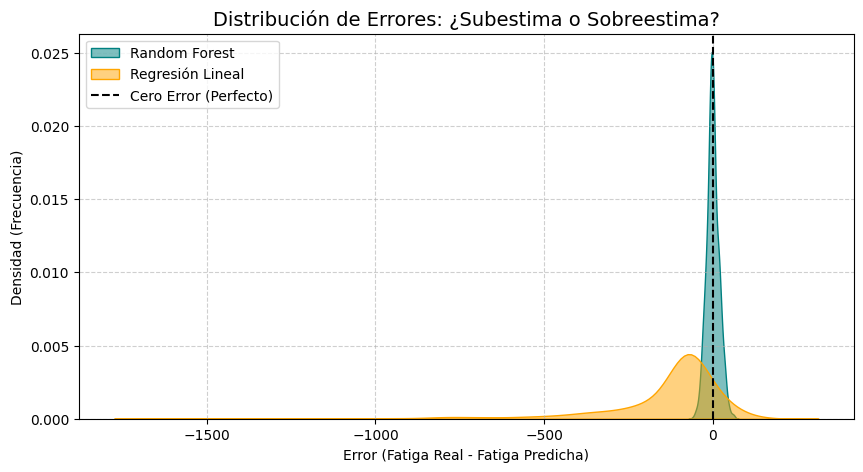

Sesgo direccional promedio Random Forest: -1.17
Interpretación:
- Si la campana está centrada exactamente en 0, el modelo no tiene un 'sesgo sistemático' (no tira consistentemente ni arriba ni abajo).
- Como vimos antes, las colas anchas a los lados demuestran que, aunque promedie bien, hay extremos donde falla duro.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculamos error direccional (Target Real - Predicción)
error_rf = y_eval - preds['Random Forest']
error_lin = y_eval - preds['Regresión Lineal']

fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(error_rf, fill=True, label='Random Forest', alpha=0.5, color='teal')
sns.kdeplot(error_lin, fill=True, label='Regresión Lineal', alpha=0.5, color='orange')

ax.axvline(0, color='black', linestyle='--', label='Cero Error (Perfecto)')
ax.set_title("Distribución de Errores: ¿Subestima o Sobreestima?", fontsize=14)
ax.set_xlabel("Error (Fatiga Real - Fatiga Predicha)")
ax.set_ylabel("Densidad (Frecuencia)")
ax.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Cálculo del sesgo promedio
print(f"Sesgo direccional promedio Random Forest: {error_rf.mean():.2f}")
print("Interpretación:")
print("- Si la campana está centrada exactamente en 0, el modelo no tiene un 'sesgo sistemático' (no tira consistentemente ni arriba ni abajo).")
print("- Como vimos antes, las colas anchas a los lados demuestran que, aunque promedie bien, hay extremos donde falla duro.")